<a href="https://colab.research.google.com/github/AnnaEzGa/Pr-ctica_2/blob/main/Pr%C3%A0ctica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -----------------------------------------------------------------
# INTRODUCTION TO MONTECARLO SIMULATION
# Simulation of 2D Ising model
# May 2018 - updated Feb 2023
# -----------------------------------------------------------------

In [23]:
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt

# 1. Definició de TOTES les funcions que utilitzarem

1.1. Definició del camp magnètic reduït

In [ ]:
h=10 # Intensitat del camp extern

1.1. Generació d'un estat inicial al·leatòri per NxN spins.

In [25]:
def initialstate(N):
    ''' generates a random spin configuration for initial condition'''
    state = 2*np.random.randint(2, size=(N,N))-1
    return state

1.2. Difinició de les interaccions del model de Ising de Magnetització 2D

In [26]:
def mcmove(config, beta):
    '''Monte Carlo move using Metropolis algorithm '''
    for i in range(N):
        for j in range(N):
                #select random spin from NxN system
                a = np.random.randint(0, N)
                b = np.random.randint(0, N)
                s =  config[a, b]
                #calculate energy cost of this new configuration (the % is for calculation of periodic boundary condition)
                nb = config[(a+1)%N,b] + config[a,(b+1)%N] + config[(a-1)%N,b] + config[a,(b-1)%N]
                cost = 2*s*(nb+h)
                #flip spin or not depending on the cost and its Boltzmann factor
                ## (acceptance probability is given by Boltzmann factor with beta = 1/kBT
                if cost < 0:
                    s *= -1
                elif rand() < np.exp(-cost*beta):
                    s *= -1
                config[a, b] = s
    return config

1.3. Definim la funció amb la que es calcularà l’energia total del sistema per una configuració completa de spins

In [27]:
def calcEnergy(config):
    '''Energy of a given configuration'''
    energy = 0
    for i in range(len(config)):
        for j in range(len(config)):
            S = config[i,j]
            nb = config[(i+1)%N, j] + config[i,(j+1)%N] + config[(i-1)%N, j] + config[i,(j-1)%N]
            energy += -nb*S
    energy /= 4.0
    energy += -h * np.sum(config)
    return energy

1.4. Definim la funció amb la que calcularem la magnetització de de l'estat/conficguració amb la que es troba el sistema

In [28]:
def calcMag(config):
    '''Magnetization of a given configuration'''
    mag = np.sum(config)
    return mag

# 2. Definició de paràmetres, valors, de normalitzacions, càlculs i distribucuions

2.1. Definició de paràmetres inicials

In [29]:
nt      = 64        # number of temperature points
N       = 16        # size of the lattice, N x N
eqSteps = 500       # number of MC sweeps for equilibration
mcSteps = 500       # number of MC sweeps for calculation

2.2. Calcular les constants de normalització per a promitjos futurs

In [30]:
n1, n2  = 1.0/(mcSteps*N*N), 1.0/(mcSteps*mcSteps*N*N)

2.3. Generar una distribució al·leatòria de temperatures

In [31]:
tm = 2.269;    T=np.random.normal(tm, .64, nt)
T  = T[(T>1.2) & (T<10)];    nt = np.size(T)

2.4. Generar llistes de zeros pels valors de energia, magnetització i de la susceptibilitat magnètica.

In [32]:
Energy       = np.zeros(nt);   Magnetization  = np.zeros(nt)
SpecificHeat = np.zeros(nt);   Susceptibility = np.zeros(nt)

# 3. Simulació del loop

Starting Simulations at  63  different temperatures.
Simulation  1  of 63  at reduced temperature T= 2.7177726219941696
Simulation  2  of 63  at reduced temperature T= 1.3740429187694967
Simulation  3  of 63  at reduced temperature T= 4.101341065299493
Simulation  4  of 63  at reduced temperature T= 1.8921983560944748
Simulation  5  of 63  at reduced temperature T= 1.4491128650180651
Simulation  6  of 63  at reduced temperature T= 2.2871517482312655
Simulation  7  of 63  at reduced temperature T= 2.27756909864842
Simulation  8  of 63  at reduced temperature T= 2.32513137895348
Simulation  9  of 63  at reduced temperature T= 2.185778415889587
Simulation  10  of 63  at reduced temperature T= 2.0390305975241367
Simulation  11  of 63  at reduced temperature T= 2.6933060101854034
Simulation  12  of 63  at reduced temperature T= 2.2224145024844897
Simulation  13  of 63  at reduced temperature T= 1.9917677556804216
Simulation  14  of 63  at reduced temperature T= 1.813399724490791
Simulation 

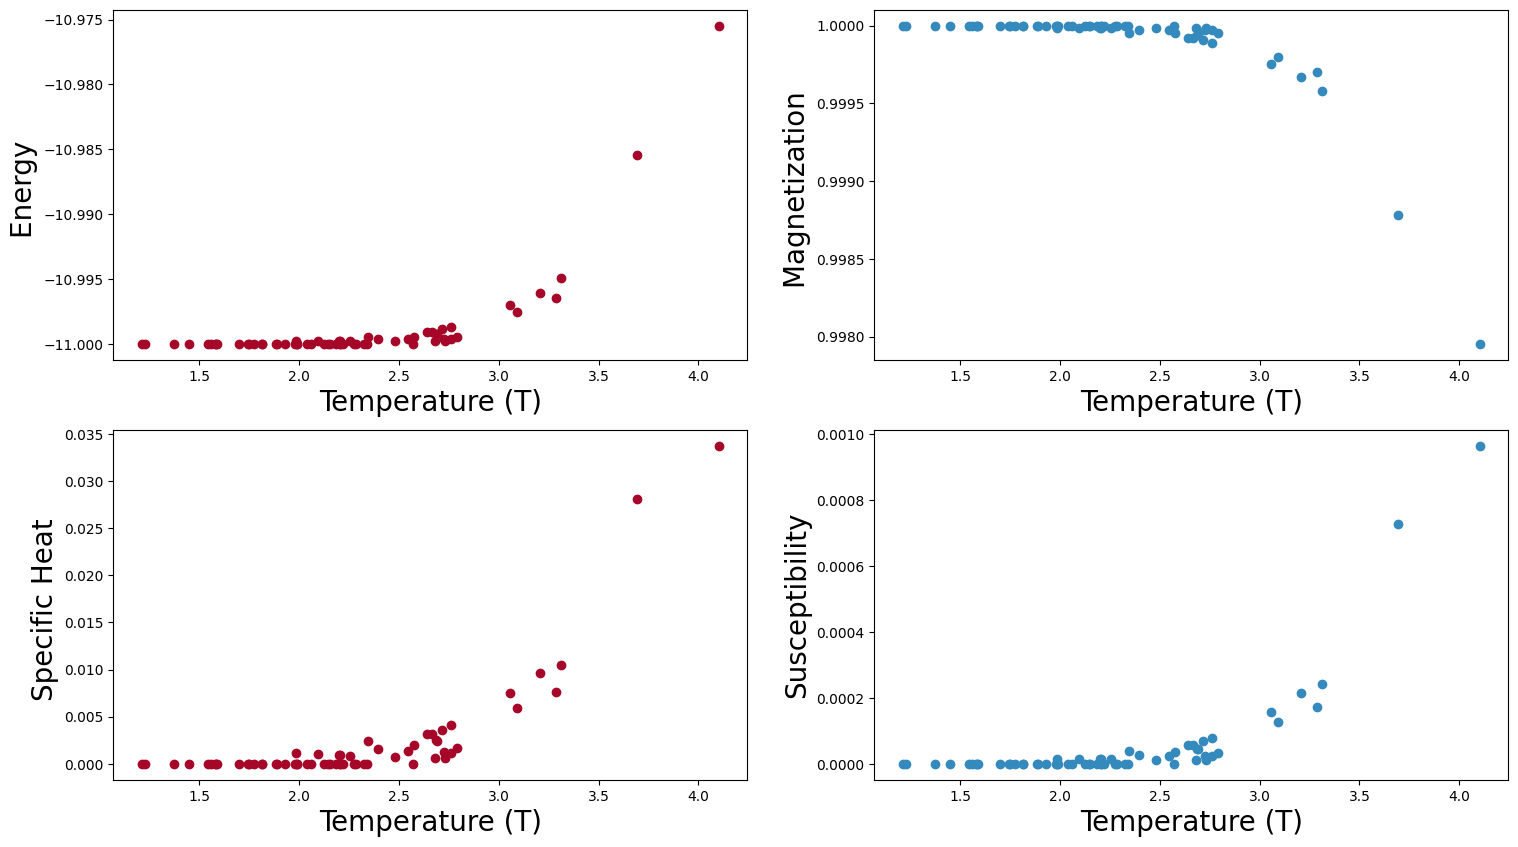

In [ ]:
print('Starting Simulations at ',len(T),' different temperatures.')
for m in range(len(T)):
    E1 = M1 = E2 = M2 = 0
    config = initialstate(N)
    iT=1.0/T[m]
    iT2=iT*iT
    print('Simulation ',m+1,' of',len(T),' at reduced temperature T=',T[m])

    for i in range(eqSteps):         # equilibrate
        mcmove(config, iT)           # Monte Carlo moves

    for i in range(mcSteps):
        mcmove(config, iT)
        Ene = calcEnergy(config)     # calculate the energy
        Mag = calcMag(config)        # calculate the magnetisation

        E1 = E1 + Ene
        M1 = M1 + Mag
        M2 = M2 + Mag*Mag
        E2 = E2 + Ene*Ene

        Energy[m]         = n1*E1
        Magnetization[m]  = n1*M1
        SpecificHeat[m]   = (n1*E2 - n2*E1*E1)*iT2
        Susceptibility[m] = (n1*M2 - n2*M1*M1)*iT

#
# Plot everything
#

f = plt.figure(figsize=(18, 10)); # plot the calculated values

sp =  f.add_subplot(2, 2, 1 );
plt.plot(T, Energy, 'o', color="#A60628");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Energy ", fontsize=20);

sp =  f.add_subplot(2, 2, 2 );
plt.plot(T, abs(Magnetization), 'o', color="#348ABD");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Magnetization ", fontsize=20);

sp =  f.add_subplot(2, 2, 3 );
plt.plot(T, SpecificHeat, 'o', color="#A60628");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Specific Heat ", fontsize=20);

sp =  f.add_subplot(2, 2, 4 );
plt.plot(T, Susceptibility, 'o', color="#348ABD");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Susceptibility", fontsize=20);
plt.show()

Ara tornem a repetir tot però per a diferents valors de h:

# Per a h=0.5:

In [24]:
h=0.5 # Intensitat del camp extern

Starting Simulations at  62  different temperatures.
Simulation  1  of 62  at reduced temperature T= 2.915630912763275
Simulation  2  of 62  at reduced temperature T= 2.2366820341743705
Simulation  3  of 62  at reduced temperature T= 2.549923188734944
Simulation  4  of 62  at reduced temperature T= 2.8527562101286756
Simulation  5  of 62  at reduced temperature T= 1.426135331340703
Simulation  6  of 62  at reduced temperature T= 3.006449811774148
Simulation  7  of 62  at reduced temperature T= 1.8221554497099473
Simulation  8  of 62  at reduced temperature T= 2.80310693475004
Simulation  9  of 62  at reduced temperature T= 2.552566564575279
Simulation  10  of 62  at reduced temperature T= 1.6403347947218614
Simulation  11  of 62  at reduced temperature T= 2.3283900099731643
Simulation  12  of 62  at reduced temperature T= 2.296730536507189
Simulation  13  of 62  at reduced temperature T= 1.3706874863633134
Simulation  14  of 62  at reduced temperature T= 2.670075012636243
Simulation  1

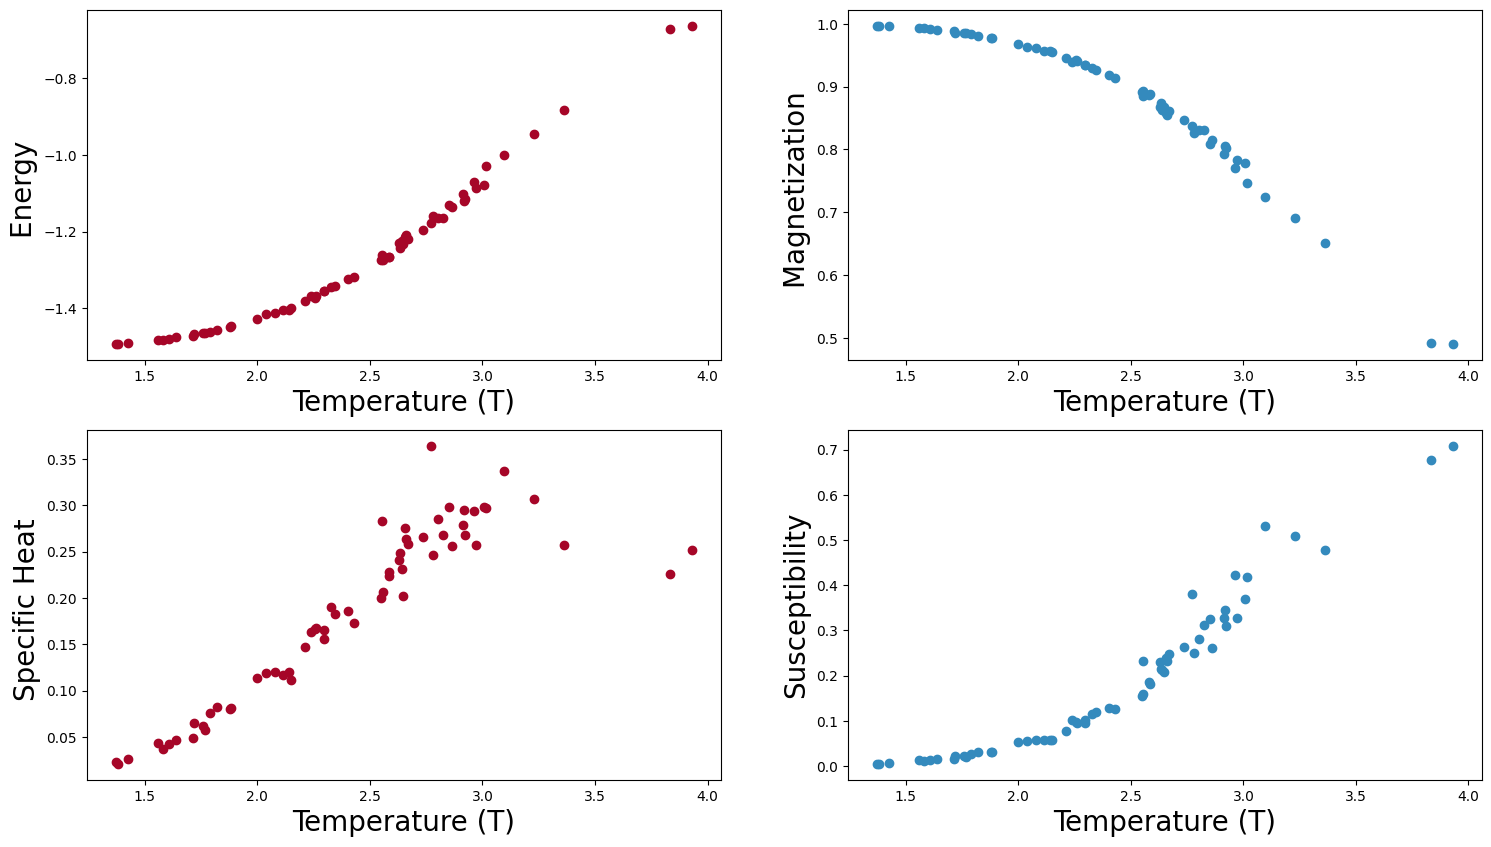

In [33]:
print('Starting Simulations at ',len(T),' different temperatures.')
for m in range(len(T)):
    E1 = M1 = E2 = M2 = 0
    config = initialstate(N)
    iT=1.0/T[m]
    iT2=iT*iT
    print('Simulation ',m+1,' of',len(T),' at reduced temperature T=',T[m])

    for i in range(eqSteps):         # equilibrate
        mcmove(config, iT)           # Monte Carlo moves

    for i in range(mcSteps):
        mcmove(config, iT)
        Ene = calcEnergy(config)     # calculate the energy
        Mag = calcMag(config)        # calculate the magnetisation

        E1 = E1 + Ene
        M1 = M1 + Mag
        M2 = M2 + Mag*Mag
        E2 = E2 + Ene*Ene

        Energy[m]         = n1*E1
        Magnetization[m]  = n1*M1
        SpecificHeat[m]   = (n1*E2 - n2*E1*E1)*iT2
        Susceptibility[m] = (n1*M2 - n2*M1*M1)*iT

#
# Plot everything
#

f = plt.figure(figsize=(18, 10)); # plot the calculated values

sp =  f.add_subplot(2, 2, 1 );
plt.plot(T, Energy, 'o', color="#A60628");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Energy ", fontsize=20);

sp =  f.add_subplot(2, 2, 2 );
plt.plot(T, abs(Magnetization), 'o', color="#348ABD");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Magnetization ", fontsize=20);

sp =  f.add_subplot(2, 2, 3 );
plt.plot(T, SpecificHeat, 'o', color="#A60628");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Specific Heat ", fontsize=20);

sp =  f.add_subplot(2, 2, 4 );
plt.plot(T, Susceptibility, 'o', color="#348ABD");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Susceptibility", fontsize=20);
plt.show()